In [1]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('https://github.com/vasilyryabtsev/futures-price-prediction/blob/vasily/twitter/tweets.csv?raw=true').drop('Unnamed: 0', axis=1)
df.head()

,username,text,is_quote_status,quote_count,reply_count,favorite_count,view_count,retweet_count,has_card,thumbnail_title,...,ticker,day,month,year,is_in_reply_to,is_view_count,open_last,close_1_day_after,close_3_day_after,close_7_day_after
0,davidfaber,The chance of $MSFT winning an appeal of the ...,0,1,43,135,113387.0,19,0,NaN,...,MSFT,26,4,2023,0,1,296.700,304.83,305.56,304.40
1,PhilipEtienne,We love and appreciate all the volunteers at t...,0,0,0,3,707.0,1,0,NaN,...,NVDA,6,5,2024,0,1,893.900,905.54,887.47,903.99
2,PhilipEtienne,Today walking the lab on the NJ beach - tomorr...,0,0,0,2,702.0,0,0,NaN,...,META,8,5,2024,0,1,463.500,475.42,468.01,481.54
3,PhilipEtienne,Today walking the lab on the NJ beach - tomorr...,0,0,0,2,702.0,0,0,NaN,...,NVDA,8,5,2024,0,1,894.825,887.47,903.99,946.30
4,PhilipEtienne,Good Morning from a dog walk on the $NVDA resc...,0,0,2,7,934.0,0,0,NaN,...,NVDA,5,5,2024,0,1,877.890,921.40,921.40,898.78


In [3]:
df.shape

(523, 22)

In [4]:
df.isna().sum()

username               0
text                   0
is_quote_status        0
quote_count            0
reply_count            0
favorite_count         0
view_count             0
retweet_count          0
has_card               0
thumbnail_title      448
urls                   0
hashtags             505
ticker                 0
day                    0
month                  0
year                   0
is_in_reply_to         0
is_view_count          0
open_last              0
close_1_day_after      0
close_3_day_after      0
close_7_day_after      0
dtype: int64

In [5]:
df = df.drop(['thumbnail_title', 'hashtags'], axis=1)

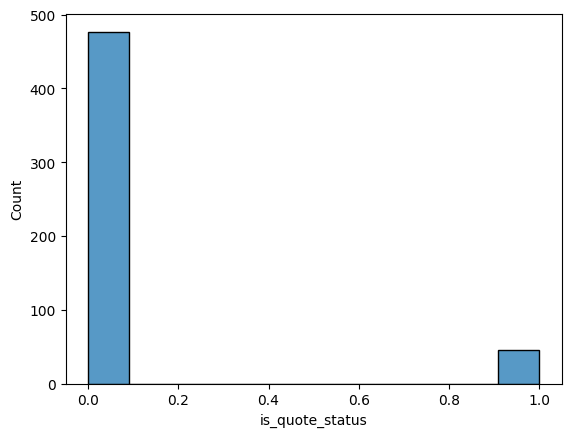

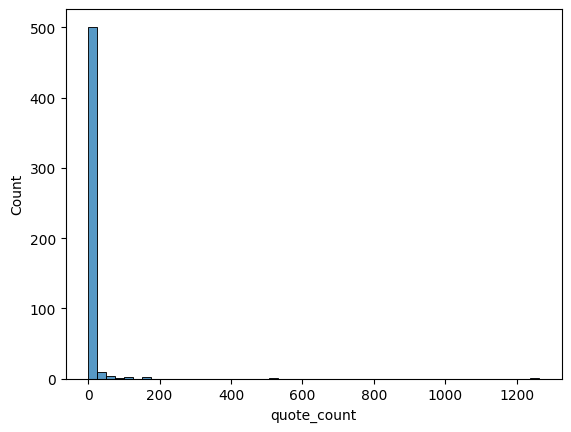

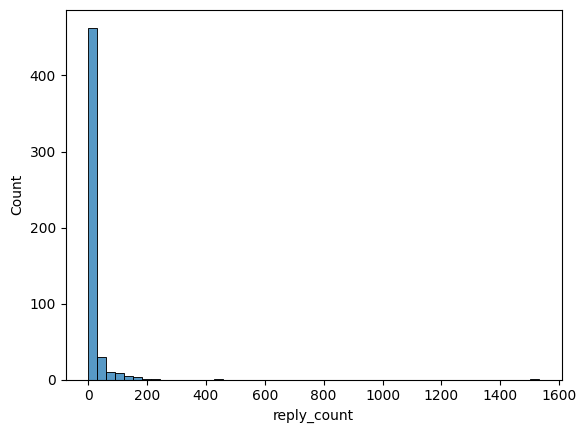

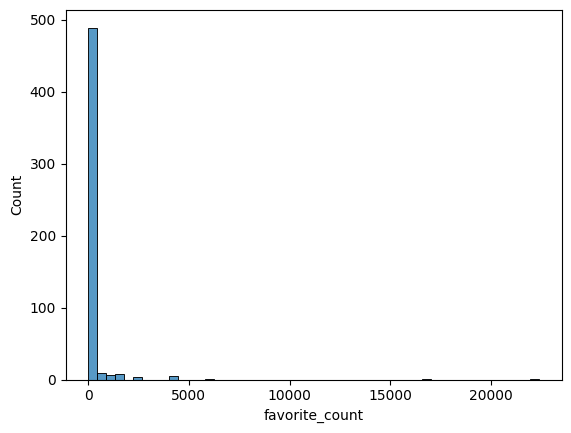

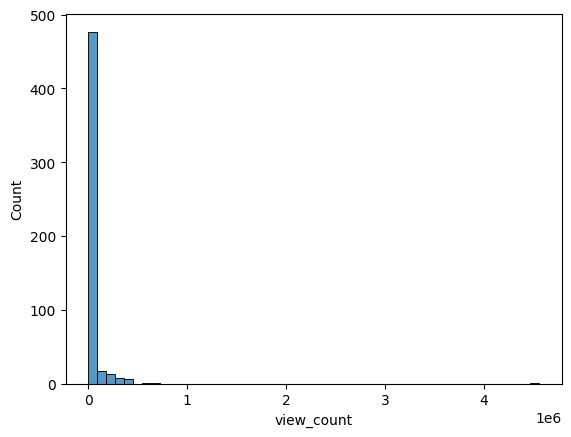

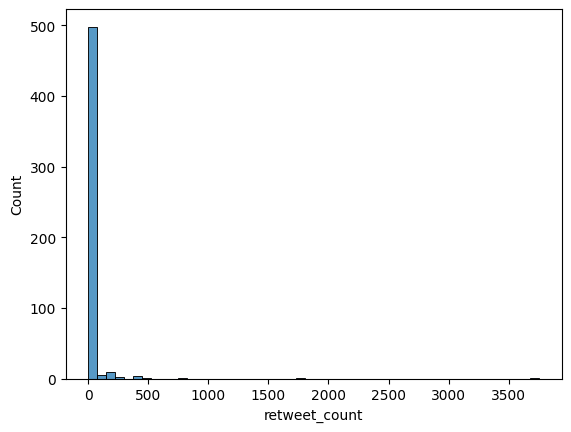

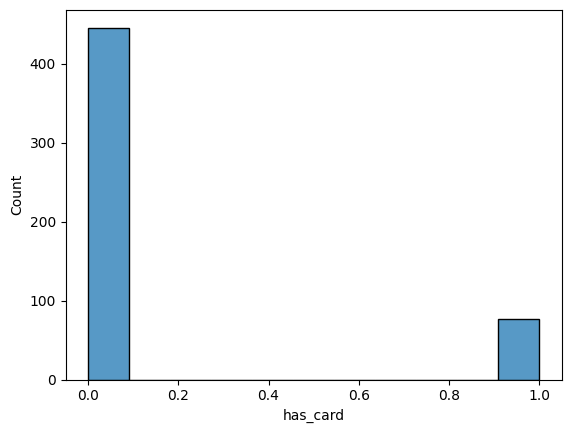

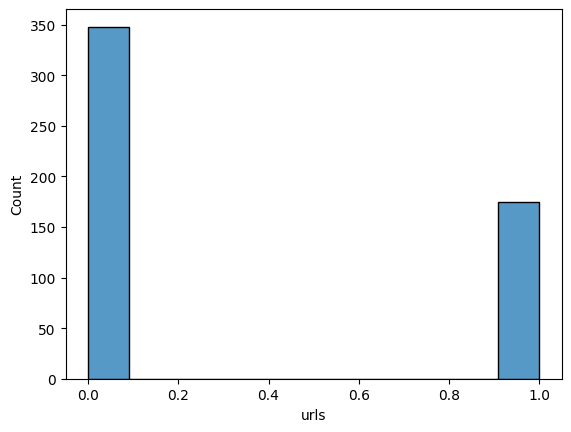

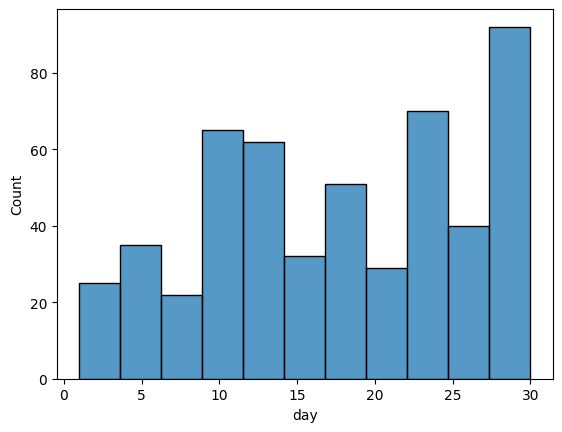

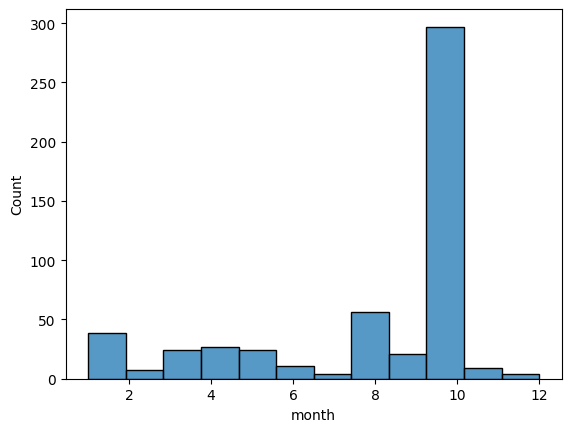

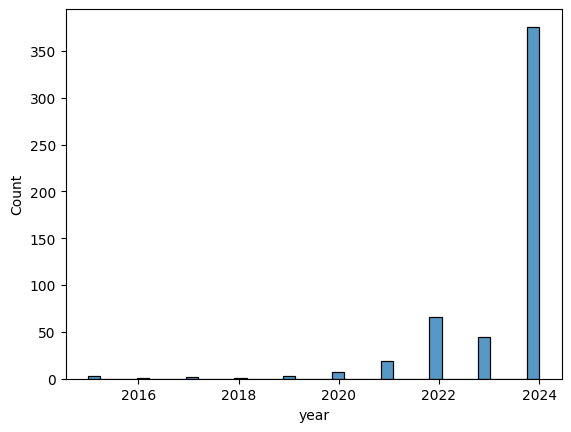

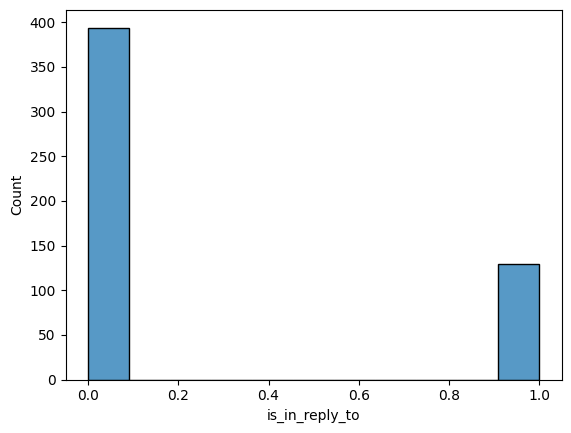

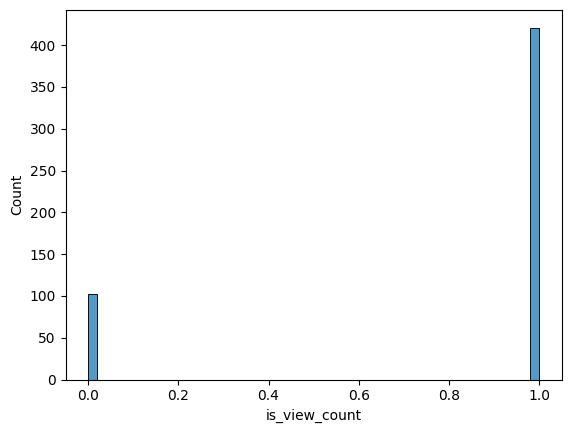

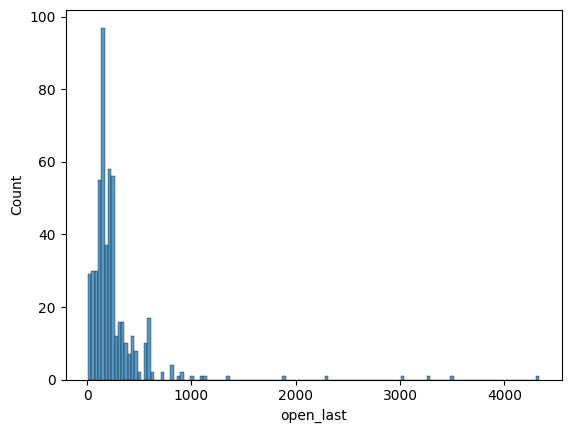

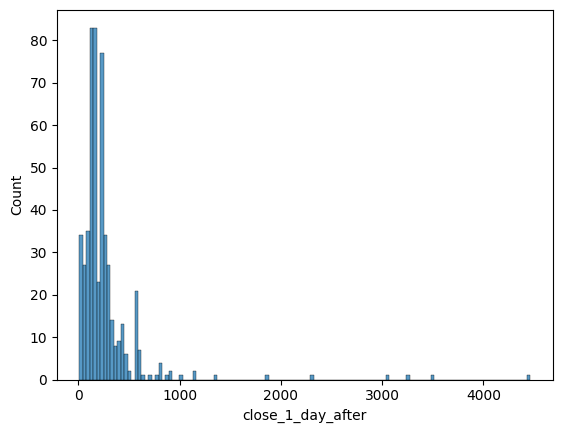

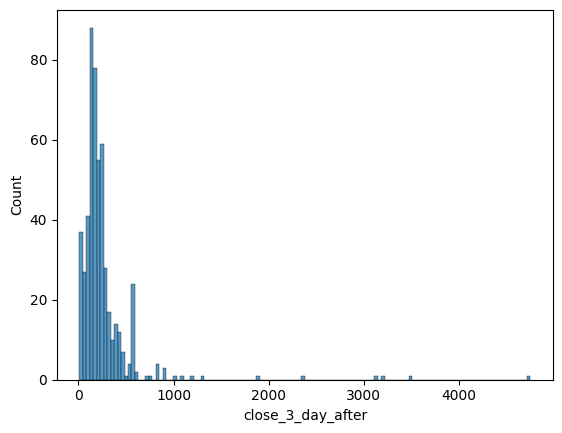

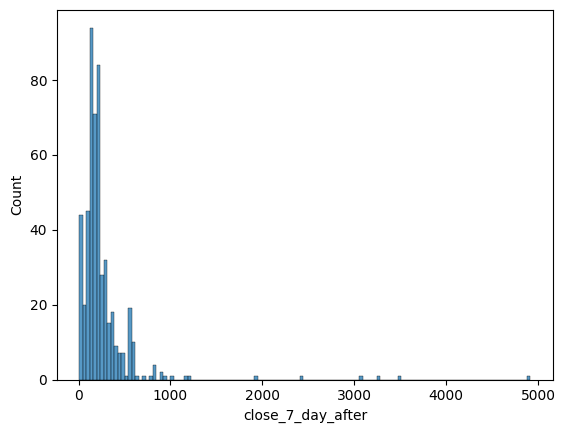

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include='number')
for col in numeric_df.columns:
    if 'count' in col:
        sns.histplot(numeric_df[col], bins=50)
    else:
        sns.histplot(numeric_df[col])
    plt.show()

### Описание атрибутов ###
- **username** - Username
- **name** - Author of the tweet
- **text** - The full text of the tweet
- **lang** - The language of the tweet
- **in_reply_to** - The tweet ID this tweet is in reply to, if any
- **is_quote_status** - Indicates if the tweet is a quote status
- **retweeted_tweet** - The Tweet being retweeted (if any)
- **possibly_sensitive** - Indicates if the tweet content may be sensitive
- **favorited** - Indicates if the tweet is favorited
- **date** - The date and time when the tweet was created
- **quote_count** - The count of quotes for the tweet
- **reply_count** - The count of replies to the tweet
- **favorite_count** - The count of favorites or likes for the tweet
- **view_count** - The count of views
- **view_count_state** - The state of the tweet views
- **retweet_count** - The count of retweets for the tweet
- **place** - The location associated with the tweet
- **is_translatable** - Indicates if the tweet is translatable
- **edits_remaining** - The remaining number of edits allowed for the tweet
- **has_card** - Indicates if the tweet contains a card
- **thumbnail_title** - The title of the webpage displayed inside the tweet’s card
- **urls** - Information about URLs contained in the tweet
- **hashtags** - Hashtags included in the tweet text

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

class СlsTargetTransformer(BaseEstimator, TransformerMixin):
    '''
    Класс трансформера, создающего таргет для задачи классификации.
    Положительная категория задается через процент минимальной прибыли.
    '''
    def __init__(self, shift_percent=0):
        """
        Инициализация трансформера с гиперпараметрами.
        :param shift_percent: Порог положительной категории таргета в процентах (опционально).
        """
        self.shift_percent = shift_percent

    def transform(self, X):
        """
        Метод transform: применяет преобразование к данным.
        :param X: Входные данные.
        :return: Преобразованные данные.
        """
        X_copy = X.copy()

        for k in [1, 3, 7]:
            col_name = f'{k}_day_after'
            X_copy[col_name] = (X_copy[f'close_{k}_day_after'] / X_copy['open_last'] - 1) * 100 - self.shift_percent
            X_copy[col_name] = X_copy[col_name].apply(lambda x: 1 if x >= 0 else 0)

        X_copy = X_copy.drop(['close_1_day_after', 'close_3_day_after', 'close_7_day_after'], axis=1)

        return X_copy

In [8]:
class_target_transformer = СlsTargetTransformer()

df0 = class_target_transformer.transform(df)

df0.head()

,username,text,is_quote_status,quote_count,reply_count,favorite_count,view_count,retweet_count,has_card,urls,ticker,day,month,year,is_in_reply_to,is_view_count,open_last,1_day_after,3_day_after,7_day_after
0,davidfaber,The chance of $MSFT winning an appeal of the ...,0,1,43,135,113387.0,19,0,0,MSFT,26,4,2023,0,1,296.700,1,1,1
1,PhilipEtienne,We love and appreciate all the volunteers at t...,0,0,0,3,707.0,1,0,0,NVDA,6,5,2024,0,1,893.900,1,0,1
2,PhilipEtienne,Today walking the lab on the NJ beach - tomorr...,0,0,0,2,702.0,0,0,0,META,8,5,2024,0,1,463.500,1,1,1
3,PhilipEtienne,Today walking the lab on the NJ beach - tomorr...,0,0,0,2,702.0,0,0,0,NVDA,8,5,2024,0,1,894.825,0,1,1
4,PhilipEtienne,Good Morning from a dog walk on the $NVDA resc...,0,0,2,7,934.0,0,0,0,NVDA,5,5,2024,0,1,877.890,1,1,1


In [9]:
target_cols = ['1_day_after', '3_day_after', '7_day_after']

for col in target_cols:
    buf = df0[col].value_counts(normalize=True)
    print(buf.to_frame())
    print('-' * 25)

             proportion
1_day_after            
1              0.531549
0              0.468451
-------------------------
             proportion
3_day_after            
1              0.531549
0              0.468451
-------------------------
             proportion
7_day_after            
1              0.560229
0              0.439771
-------------------------


In [10]:
import seaborn as sns

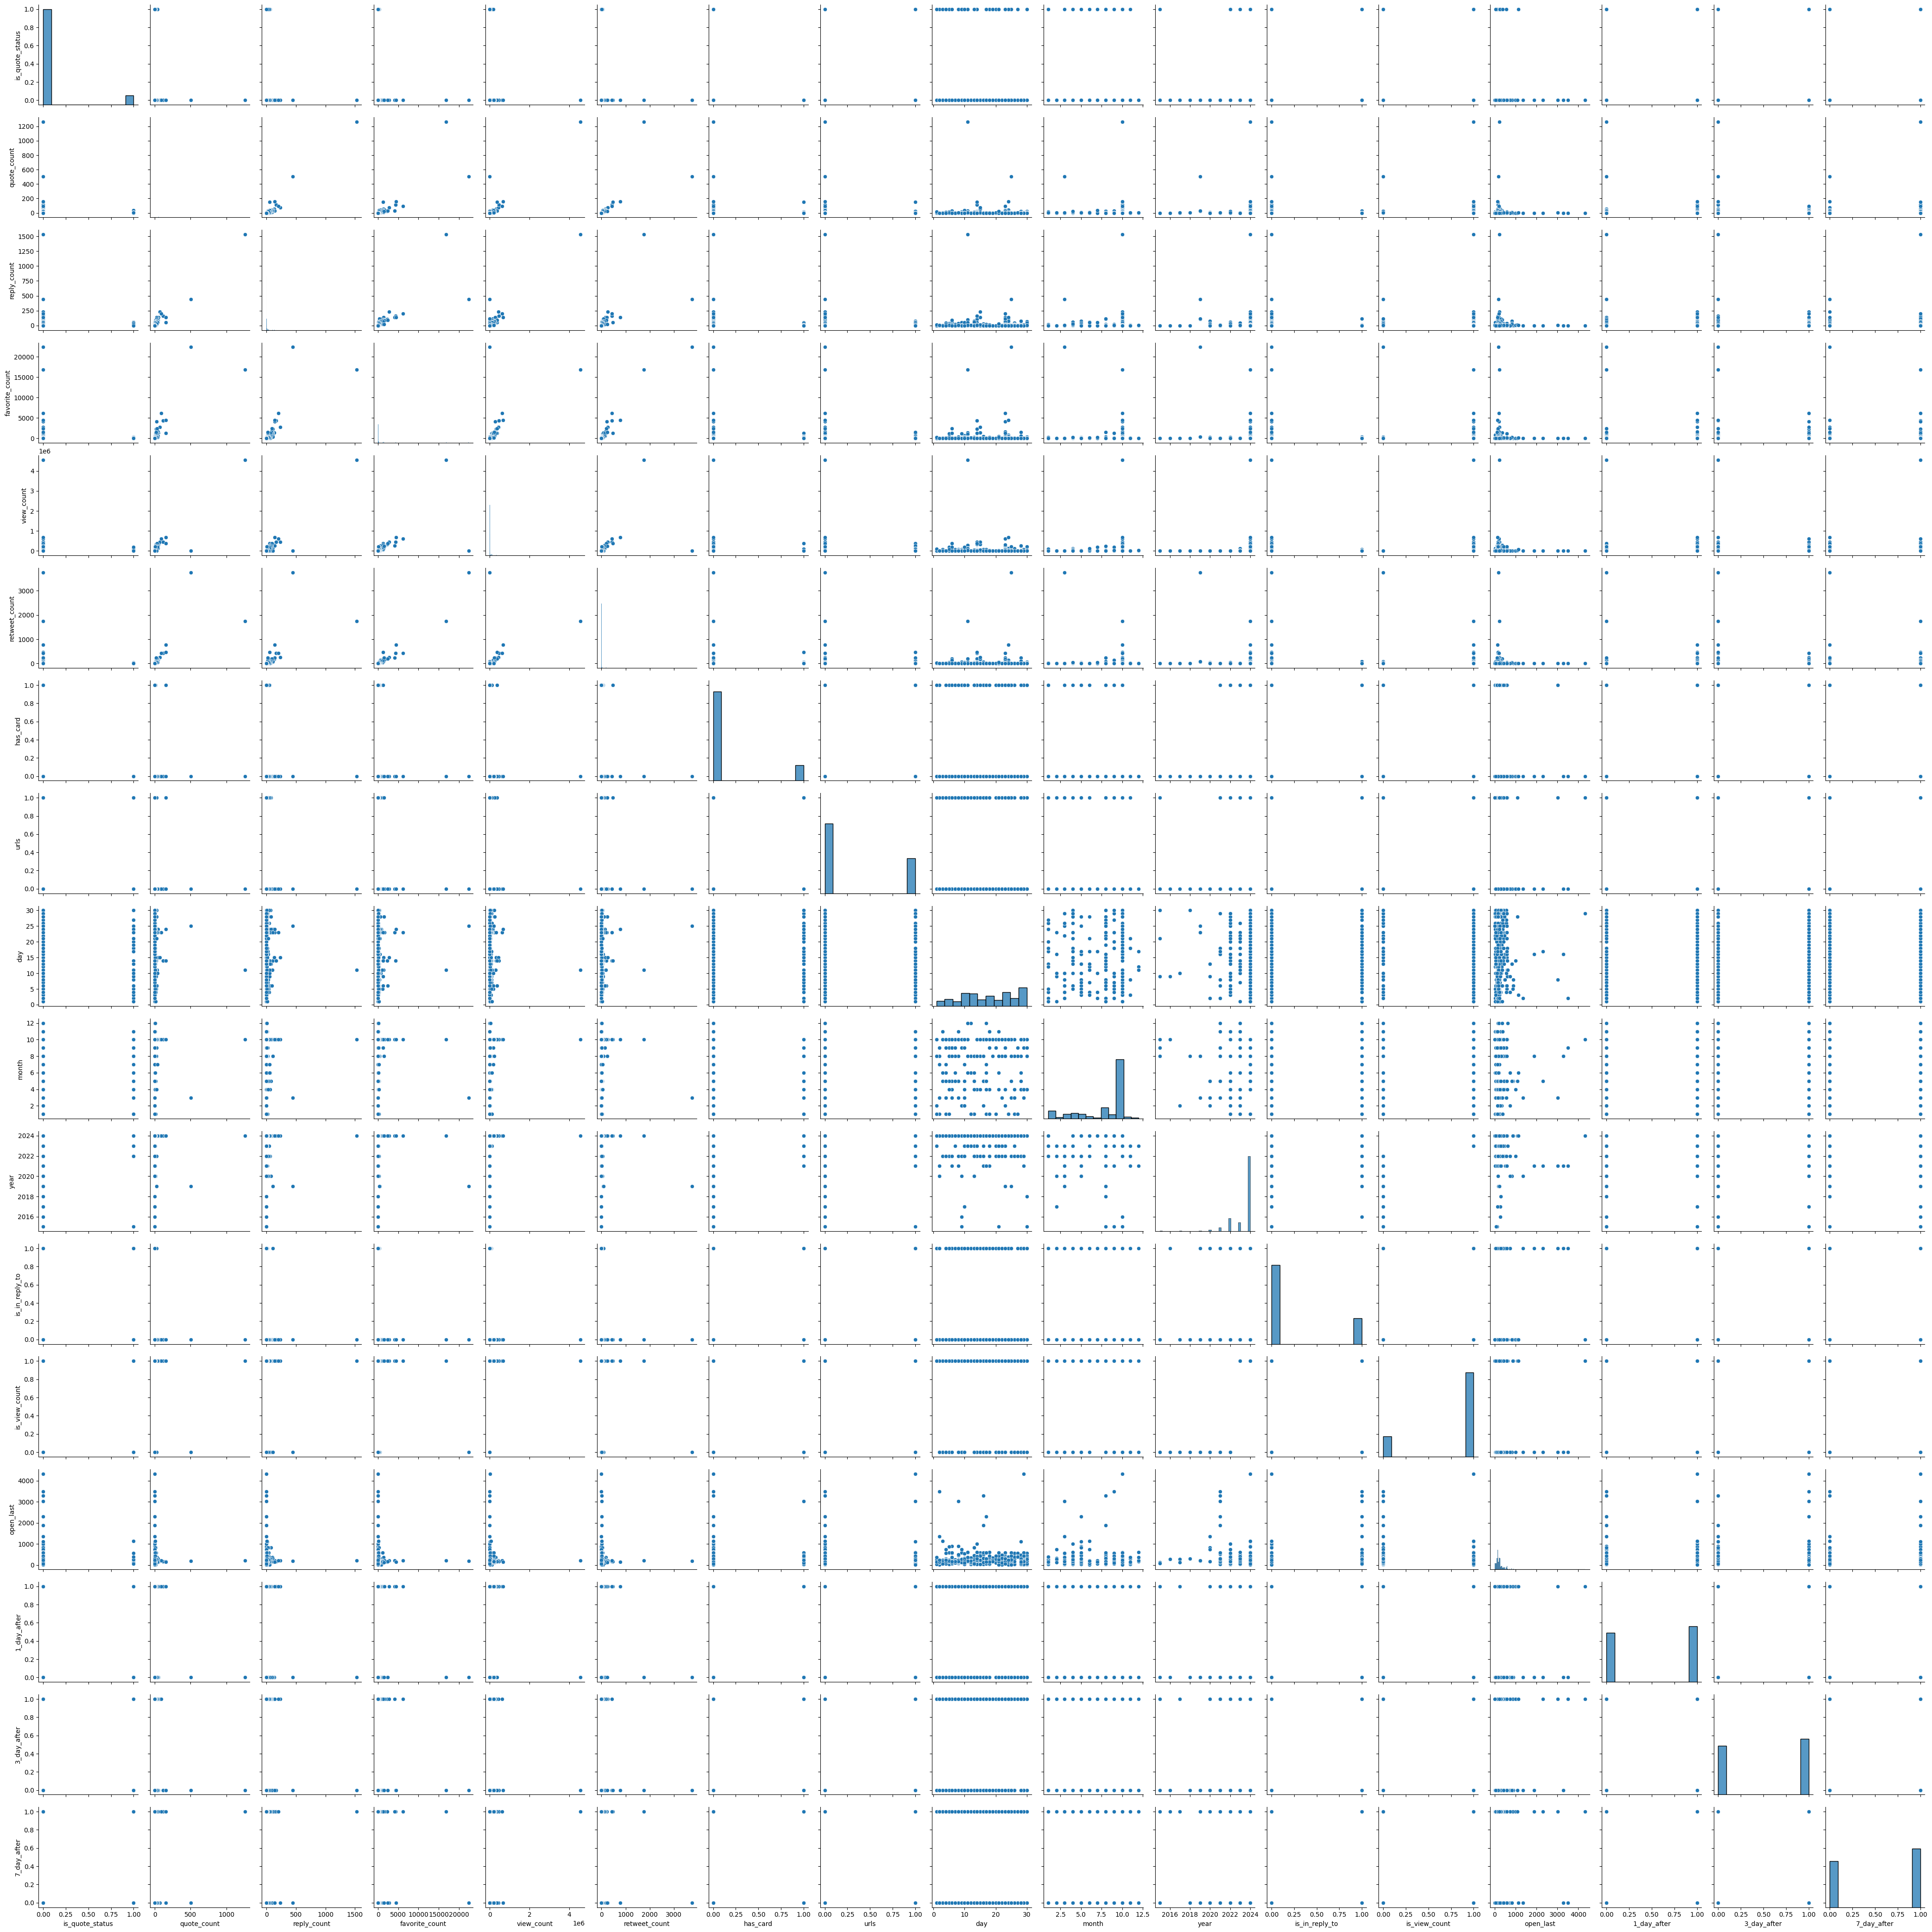

In [11]:
sns.pairplot(df0)

In [12]:
df0_corr = df0.select_dtypes(include='number').corr()
df0_corr

,is_quote_status,quote_count,reply_count,favorite_count,view_count,retweet_count,has_card,urls,day,month,year,is_in_reply_to,is_view_count,open_last,1_day_after,3_day_after,7_day_after
is_quote_status,1.000000,-0.027628,-0.038608,-0.039846,-0.036748,-0.035640,-0.129032,-0.191602,-0.093919,0.012251,0.031960,-0.115047,0.033588,-0.068050,0.007424,0.061539,0.057524
quote_count,-0.027628,1.000000,0.963968,0.838044,0.911751,0.742303,-0.026504,-0.054515,-0.023557,0.025569,-0.017657,-0.063451,0.003892,-0.018943,-0.042729,-0.074533,0.025788
reply_count,-0.038608,0.963968,1.000000,0.801718,0.943525,0.667696,-0.055389,-0.083282,-0.023166,0.060145,0.004294,-0.099869,0.023711,-0.023250,-0.034755,-0.047957,0.039864
favorite_count,-0.039846,0.838044,0.801718,1.000000,0.635923,0.963313,-0.052537,-0.085262,0.004087,0.018970,-0.054641,-0.089349,-0.012199,-0.027414,-0.028022,-0.062749,0.011759
view_count,-0.036748,0.911751,0.943525,0.635923,1.000000,0.470061,-0.033977,-0.056569,-0.030767,0.097203,0.087160,-0.092879,0.090752,-0.024045,-0.015424,-0.038500,0.049728
retweet_count,-0.035640,0.742303,0.667696,0.963313,0.470061,1.000000,-0.030787,-0.058557,0.017391,-0.006683,-0.088791,-0.078551,-0.038535,-0.025514,-0.036120,-0.074169,-0.014348
has_card,-0.129032,-0.026504,-0.055389,-0.052537,-0.033977,-0.030787,1.000000,0.574498,0.033538,0.079157,0.131339,-0.075014,0.122806,-0.002563,0.033207,0.000765,-0.001497
urls,-0.191602,-0.054515,-0.083282,-0.085262,-0.056569,-0.058557,0.574498,1.000000,0.168875,0.214153,0.210654,-0.208356,0.216099,-0.001775,0.007950,-0.024533,-0.024819
day,-0.093919,-0.023557,-0.023166,0.004087,-0.030767,0.017391,0.033538,0.168875,1.000000,0.122584,0.093922,-0.126945,0.074224,-0.052732,-0.074397,-0.106066,-0.200380
month,0.012251,0.025569,0.060145,0.018970,0.097203,-0.006683,0.079157,0.214153,0.122584,1.000000,0.352167,-0.283961,0.353669,-0.078715,0.109850,0.059323,0.023463


<Axes: >

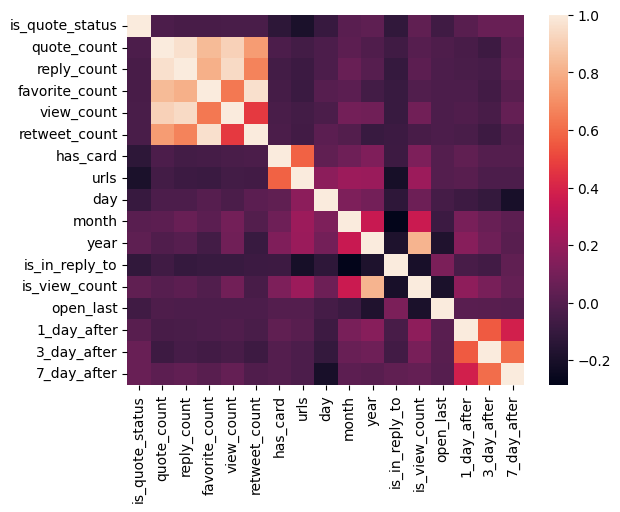

In [13]:
sns.heatmap(df0_corr)

# Текстовые признаки

## Bag Of Words

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(df0['text'].to_frame(), df0['1_day_after'], test_size=0.1, random_state=RANDOM_STATE)

vec = CountVectorizer(ngram_range=(1, 1), stop_words='english')

X_train = vec.fit_transform(X_train['text'])
X_test = vec.transform(X_test['text'])

scaler = MaxAbsScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

pred_train = clf.predict(X_train)
pred_test = clf.predict(X_test)

print('accuracy (train, test):', accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test))
print('roc-auc (train, test):', roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_test))

accuracy (train, test): 0.9319148936170213 0.5849056603773585
roc-auc (train, test): 0.9311665214866435 0.574404761904762


Переобучение. Изменение ngram_range проблему не решило.

In [17]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.48      0.52      0.50        21
           1       0.67      0.62      0.65        32

    accuracy                           0.58        53
   macro avg       0.57      0.57      0.57        53
weighted avg       0.59      0.58      0.59        53



## Tf-idf

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(df0['text'].to_frame(), df0['1_day_after'], test_size=0.1, random_state=RANDOM_STATE)

vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 1)) # ngram_range = (1,1) - векторизуем только отдельные слова

X_train = vec.fit_transform(X_train['text'])
X_test = vec.transform(X_test['text'])

scaler = MaxAbsScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

pred_train = clf.predict(X_train)
pred_test = clf.predict(X_test)

print('accuracy (train, test):', accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test))
print('roc-auc (train, test):', roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_test))

accuracy (train, test): 0.9319148936170213 0.6226415094339622
roc-auc (train, test): 0.9311665214866435 0.605654761904762


Переобучение. Изменение ngram_range проблему не решило.

In [23]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.52      0.52      0.52        21
           1       0.69      0.69      0.69        32

    accuracy                           0.62        53
   macro avg       0.61      0.61      0.61        53
weighted avg       0.62      0.62      0.62        53



## [finbert-tone](https://huggingface.co/yiyanghkust/finbert-tone?text=growth+is+strong+and+we+have+plenty+of+liquidity)

In [24]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline

finbert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone',num_labels=3)
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer)

sentences = "there is a shortage of capital, and we need extra financing"
results = nlp(sentences)
print(results)  #LABEL_0: neutral; LABEL_1: positive; LABEL_2: negative

/home/vasily/futures-price-prediction/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[{'label': 'Negative', 'score': 0.9966173768043518}]


In [ ]:
class FinBertTransformer(BaseEstimator, TransformerMixin):
    '''
    Добавляет в датасет два новых признака, полученных из text:
    label - оценка текста Negative/Positive/Neutral
    score - уверенность в оценке 0.0 - 1.0 float
    '''
    def __init__(self, pipe):
        self.pipe = pipe

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy['text'] = X_copy['text'].apply(self.pipe)
        X_copy['label'] = X_copy['text'].apply(lambda x: x[0]['label'])
        X_copy['score'] = X_copy['text'].apply(lambda x: x[0]['score'])

        return X_copy.drop('text', axis=1)

In [ ]:
nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer)
finbert_score = FinBertTransformer(nlp)

fbt = finbert_score.fit_transform(X_train)
fbt_test = finbert_score.transform(X_test)

fbt = pd.get_dummies(fbt, 'label', drop_first=True)
fbt_test = pd.get_dummies(fbt_test, 'label', drop_first=True)

clf = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
clf.fit(fbt, y_train)

pred_train = clf.predict(fbt)
pred_test = clf.predict(fbt_test)

accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test)

(0.548936170212766, 0.5660377358490566)

Переобучения нет!

In [ ]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.59      0.94      0.72        32

    accuracy                           0.57        53
   macro avg       0.29      0.47      0.36        53
weighted avg       0.36      0.57      0.44        53



![image.png](attachment:image.png)

## [finbert ProcusAI](https://huggingface.co/ProsusAI/finbert)

In [ ]:
nlp = pipeline("text-classification", model="ProsusAI/finbert")
finbert_score = FinBertTransformer(nlp)

fbt = finbert_score.fit_transform(X_train)
fbt_test = finbert_score.transform(X_test)

fbt = pd.get_dummies(fbt, 'label', drop_first=True)
fbt_test = pd.get_dummies(fbt_test, 'label', drop_first=True)

clf = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
clf.fit(fbt, y_train)

pred_train = clf.predict(fbt)
pred_test = clf.predict(fbt_test)

accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test)

(0.5702127659574469, 0.6415094339622641)

Небольшое переобучение

In [ ]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.58      0.33      0.42        21
           1       0.66      0.84      0.74        32

    accuracy                           0.64        53
   macro avg       0.62      0.59      0.58        53
weighted avg       0.63      0.64      0.61        53



In [69]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Загрузка модели и токенизатора
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Токенезация
tokenized = df0['text'].apply((lambda x: tokenizer.encode(x, add_special_tokens=True)))

# Паддинг (чтобы все тексты были одинаковой длины)
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)
padded = np.array([i + [0]*(max_len-len(i)) for i in tokenized.values])

# Masking (нужно показать модели, что все нули это пустое место)
attention_mask = np.where(padded != 0, 1, 0)
input_ids = torch.tensor(padded)
attention_mask = torch.tensor(attention_mask)

# Применение модели
with torch.no_grad():
    last_hidden_states = model(input_ids, attention_mask=attention_mask)

features = last_hidden_states[0].numpy()

X_train, X_test, y_train, y_test = train_test_split(features, df0['1_day_after'], test_size=0.1, random_state=RANDOM_STATE)

clf = LogisticRegression()
clf.fit(X_train, y_train)

pred_train = clf.predict(X_train)
pred_test = clf.predict(X_test)

accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test)

(0.5404255319148936, 0.6226415094339622)

In [71]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.54      0.33      0.41        21
           1       0.65      0.81      0.72        32

    accuracy                           0.62        53
   macro avg       0.59      0.57      0.57        53
weighted avg       0.61      0.62      0.60        53



## Word2vec

In [ ]:
from gensim.models import Word2Vec

sent = [row.split() for row in X_train['text']]

HIDDEN = 100 # каждое слово закодированно числовым вектором длины 100

model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=HIDDEN,
                     sample=6e-5,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     workers=2)
model.build_vocab(sent, progress_per=10000) # собираем словарь слов
model.train(sent, total_examples=model.corpus_count, epochs=30, report_delay=1)

(9279, 402030)

In [ ]:
def get_mean_w2v_vector(sentence):
    Sum = 0
    Count = 0

    try:
      words = sentence.split()
    except TypeError:
      words = []

    for w in words:
        if w in model.wv:
            Sum += model.wv[w]
            # Sum += glove_vectors[w]
            Count += 1

    if Count == 0:
        return 0

    return Sum / Count

In [ ]:
NewCols = ['col'+str(i) for i in range(HIDDEN)]

X_train['vectors'] = X_train.map(get_mean_w2v_vector)
X_test['vectors'] = X_test.map(get_mean_w2v_vector)

X_train.head()

,text,vectors
511,The mega-caps have 10-bagged their market cap ...,"[-0.1904228, 0.14006463, -0.07061442, -0.00465..."
218,$NFLX slide - global subscriber map https://t....,"[-0.20443557, 0.15456751, -0.0815164, 0.003685..."
210,Q4/22 results from $NFLX (out 1/19/23) will be...,"[-0.2001193, 0.1457692, -0.07549616, -0.001877..."
124,NVIDIA $NVDA is back to 13.7% above its 50-DMA...,"[-0.19319382, 0.14565031, -0.0745226, -0.00593..."
180,Nvidia has added $484 billion in market cap ov...,"[-0.20058219, 0.14940384, -0.0731379, -0.00228..."


In [ ]:
IdxTrain = []

for ix, row in X_train.iterrows():
    if not isinstance(row['vectors'],np.ndarray):
        IdxTrain.append(ix)

IdxTest = []

for ix, row in X_test.iterrows():
    if not isinstance(row['vectors'],np.ndarray):
        IdxTest.append(ix)

In [ ]:
X_train.drop(index=IdxTrain, inplace=True)
X_test.drop(index=IdxTest, inplace=True)

y_train = y_train.drop(index=IdxTrain)
y_test = y_test.drop(index=IdxTest)

In [ ]:
X_train[NewCols] = pd.DataFrame(X_train['vectors'].tolist(), index=X_train.index)
X_test[NewCols] = pd.DataFrame(X_test['vectors'].tolist(), index=X_test.index)

/tmp/ipykernel_1649/1430828587.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[NewCols] = pd.DataFrame(X_train['vectors'].tolist(), index=X_train.index)
/tmp/ipykernel_1649/1430828587.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[NewCols] = pd.DataFrame(X_train['vectors'].tolist(), index=X_train.index)
/tmp/ipykernel_1649/1430828587.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all

In [ ]:
X_train.head()

,text,vectors,col0,col1,col2,col3,col4,col5,col6,col7,...,col90,col91,col92,col93,col94,col95,col96,col97,col98,col99
511,The mega-caps have 10-bagged their market cap ...,"[-0.1904228, 0.14006463, -0.07061442, -0.00465...",-0.190423,0.140065,-0.070614,-0.004659,0.055311,-0.330717,0.168278,0.395217,...,0.305071,0.154007,-0.003953,-0.068403,0.404041,0.297493,-0.008369,-0.261916,0.013769,-0.060473
218,$NFLX slide - global subscriber map https://t....,"[-0.20443557, 0.15456751, -0.0815164, 0.003685...",-0.204436,0.154568,-0.081516,0.003686,0.066605,-0.353416,0.182013,0.426739,...,0.334689,0.161903,-0.010292,-0.071033,0.431926,0.312294,-0.012148,-0.280096,0.016558,-0.060694
210,Q4/22 results from $NFLX (out 1/19/23) will be...,"[-0.2001193, 0.1457692, -0.07549616, -0.001877...",-0.200119,0.145769,-0.075496,-0.001877,0.059619,-0.335673,0.172102,0.403198,...,0.316222,0.157888,-0.005731,-0.069332,0.409200,0.300467,-0.008615,-0.265658,0.015349,-0.055800
124,NVIDIA $NVDA is back to 13.7% above its 50-DMA...,"[-0.19319382, 0.14565031, -0.0745226, -0.00593...",-0.193194,0.145650,-0.074523,-0.005939,0.059673,-0.336297,0.170921,0.404497,...,0.310518,0.157886,-0.002936,-0.066716,0.411724,0.303644,-0.006842,-0.266296,0.015543,-0.060415
180,Nvidia has added $484 billion in market cap ov...,"[-0.20058219, 0.14940384, -0.0731379, -0.00228...",-0.200582,0.149404,-0.073138,-0.002286,0.055531,-0.344475,0.177997,0.415603,...,0.322787,0.164471,-0.003659,-0.068473,0.424915,0.312205,-0.010947,-0.273887,0.014748,-0.058219


In [ ]:
X_train.drop(['text','vectors'], axis=1, inplace=True)
X_test.drop(['text','vectors'], axis=1, inplace=True)

In [ ]:
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

lr_train_pred = lr_clf.predict(X_train)
lr_test_pred = lr_clf.predict(X_test)

accuracy_score(y_train, lr_train_pred), accuracy_score(y_test, lr_test_pred)

(0.5227765726681128, 0.6037735849056604)

Переобучения нет, но качество очень низкое